<a href="https://www.kaggle.com/code/zikriazzuri/zomato-india-features-ratings-analysis?scriptVersionId=356570241" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Apakah Online Delivery dan Table Booking Meningkatkan Rating Restoran?
Analisis data restoran Zomato di India dengan kontrol tingkat harga.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt



# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os

os.makedirs("images", exist_ok=True)
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/zikriazzuri/zomato/Zomato Restaurant Dataset.csv


## Pertanyaan bisnis
Pemilik restoran ingin rating yang lebih tinggi. Apakah restoran dengan **online delivery** atau **table booking** punya rating lebih tinggi?

Dua fitur lain (`Is delivering now`, `Switch to order menu`) tidak dipakai karena tidak bisa membedakan restoran (lihat pemeriksaan di bawah).

In [2]:
df = pd.read_csv('/kaggle/input/datasets/zikriazzuri/zomato/Zomato Restaurant Dataset.csv')

print(df.shape)
print(df.info())
print(df.describe())

(9551, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to 

## Pemeriksaan data
- Data berisi 9.551 restoran dan 21 kolom.
- Hanya `Cuisines` yang punya nilai kosong (9 baris), dan kolom ini tidak dipakai di analisis ini.
- `Votes` sangat miring: rata-rata 157, median 31.
- `Price range` bernilai 1 (termurah) sampai 4 (termahal).

In [3]:
print(df['Has Table booking'].value_counts())
print(df['Has Online delivery'].value_counts())
print(df['Is delivering now'].value_counts())
print(df['Switch to order menu'].value_counts())

Has Table booking
No     8393
Yes    1158
Name: count, dtype: int64
Has Online delivery
No     7100
Yes    2451
Name: count, dtype: int64
Is delivering now
No     9517
Yes      34
Name: count, dtype: int64
Switch to order menu
No    9551
Name: count, dtype: int64


- Table booking: 1.158 restoran "Yes" (sekitar 12%). Online delivery: 2.451 "Yes" (sekitar 26%). Keduanya cukup untuk dibandingkan.
- `Is delivering now` hanya 34 "Yes", dan `Switch to order menu` seluruhnya "No", sehingga keduanya tidak dipakai.

In [4]:
ar = df['Aggregate rating'] == 0
print(ar.sum())
pd.crosstab(ar, df['Rating text'])

2148


Rating text,Average,Excellent,Good,Not rated,Poor,Very Good
Aggregate rating,,,,,,
False,3737,301,2100,0,186,1079
True,0,0,0,2148,0,0


- Ada 2.148 restoran berating 0, dan semuanya berstatus "Not rated" (belum dinilai), bukan restoran buruk. Restoran ini dibuang dari perbandingan rating, sehingga tersisa 7.403 restoran.

In [5]:
unrated = df[df['Aggregate rating'] == 0]
print(unrated['Has Online delivery'].value_counts(normalize=True).round(3))
print(unrated['Has Table booking'].value_counts(normalize=True).round(3))

print(df.groupby('Has Online delivery')['Aggregate rating'].agg(['mean', 'count']))
print(df.groupby('Has Table booking')['Aggregate rating'].agg(['mean', 'count']))

Has Online delivery
No     0.955
Yes    0.045
Name: proportion, dtype: float64
Has Table booking
No     0.978
Yes    0.022
Name: proportion, dtype: float64
                         mean  count
Has Online delivery                 
No                   2.465296   7100
Yes                  3.248837   2451
                       mean  count
Has Table booking                 
No                 2.559359   8393
Yes                3.441969   1158


- Jika restoran yang belum dinilai ikut dihitung, selisih rating tampak besar: delivery +0,78 (3,25 vs 2,47) dan booking +0,88 (3,44 vs 2,56). Penyebabnya, 95,5% restoran yang belum dinilai tidak punya delivery dan 97,8% tidak punya booking.
- Setelah restoran itu dibuang, selisihnya menyusut menjadi -0,09 untuk delivery dan +0,17 untuk booking, lalu tidak konsisten setelah harga dikontrol.

## Analisis awal (semua negara)

In [6]:
df_rated = df[df['Aggregate rating'] > 0]

rating_tb_all = df_rated.groupby('Has Table booking').agg({
    'Aggregate rating': ['median', 'mean', 'count']
})

rating_od_all = df_rated.groupby('Has Online delivery').agg({
    'Aggregate rating': ['median', 'mean', 'count']
})
 
print(rating_tb_all)
print(rating_od_all)


                  Aggregate rating                
                            median      mean count
Has Table booking                                 
No                             3.4  3.413970  6292
Yes                            3.6  3.587579  1111
                    Aggregate rating                
                              median      mean count
Has Online delivery                                 
No                               3.4  3.467433  5048
Yes                              3.4  3.381274  2355


- Setelah restoran yang belum dinilai dibuang, rata-rata rating restoran dengan booking sedikit lebih tinggi (3,59 vs 3,41), sedangkan delivery sedikit lebih rendah (3,38 vs 3,47). Harga belum dikontrol.

In [7]:
df_rated.groupby(['Price range', 'Has Table booking']).agg({
    'Aggregate rating': ['mean', 'count']
})

Aggregate rating      
                                          mean count
Price range Has Table booking                       
1           No                        3.238717  2743
            Yes                       3.700000     1
2           No                        3.377800  2491
            Yes                       3.370000   220
3           No                        3.911883   749
            Yes                       3.615705   624
4           No                        4.054369   309
            Yes                       3.701128   266

- Harga 1 hanya punya 1 restoran dengan booking, jadi diabaikan. Di harga 2 ratingnya hampir sama (3,37 vs 3,38). Di harga 3 dan 4, restoran tanpa booking justru lebih tinggi.

In [8]:
df_rated.groupby(['Price range', 'Has Online delivery']).agg({
    'Aggregate rating': ['mean', 'count']
})

Aggregate rating      
                                            mean count
Price range Has Online delivery                       
1           No                          3.231870  2096
            Yes                         3.261574   648
2           No                          3.414325  1466
            Yes                         3.333414  1245
3           No                          3.833195   964
            Yes                         3.645477   409
4           No                          3.886973   522
            Yes                         3.930189    53

- Selisih rating delivery kecil dan arahnya campur: sedikit lebih tinggi di harga 1 dan 4, sedikit lebih rendah di harga 2 dan 3. Rating naik seiring tingkat harga.

In [9]:
df_rated['Votes'].describe()

count     7403.000000
mean       202.185060
std        479.195199
min          4.000000
25%         19.000000
50%         60.000000
75%        181.000000
max      10934.000000
Name: Votes, dtype: float64

- Rata-rata votes (202) jauh di atas median (60), dengan maksimum 10.934. Distribusi miring ke kanan, jadi perbandingan votes memakai median.

In [10]:
votes_tb_all = df_rated.groupby('Has Table booking').agg({
    'Votes': ['median', 'mean', 'count']
})

votes_od_all = df_rated.groupby('Has Online delivery').agg({
    'Votes': ['median', 'mean', 'count']
})

print(votes_od_all)
print(votes_tb_all)

                     Votes                  
                    median        mean count
Has Online delivery                         
No                    47.0  193.940174  5048
Yes                   84.0  219.858174  2355
                   Votes                  
                  median        mean count
Has Table booking                         
No                  49.0  172.905912  6292
Yes                165.0  368.003600  1111


- Median votes restoran dengan fitur lebih tinggi: delivery 84 vs 47, booking 165 vs 49. Harga belum dikontrol, jadi perlu dicek per tingkat harga.

In [11]:
country_counts = df['Country Code'].value_counts()
share = country_counts / len(df)

print(f"Jumlah negara: {df['Country Code'].nunique()}")
print(f"Jumlah mata uang: {df['Currency'].nunique()}")
print(f"Restoran India (Country Code 1): {country_counts.loc[1]} dari {len(df)} ({share.loc[1]:.1%})")
print(f"Negara terbesar kedua: {share.iloc[1]:.1%} dari data")
print(df.loc[df['Country Code'] == 1, 'Currency'].unique())

Jumlah negara: 15
Jumlah mata uang: 12
Restoran India (Country Code 1): 8652 dari 9551 (90.6%)
Negara terbesar kedua: 4.5% dari data
['Indian Rupees(Rs.)']


### Mengapa analisis dibatasi ke India
- Sekitar 90,6% restoran berada di India (Country Code 1), sedangkan negara lain masing-masing hanya sebagian kecil data.
- Data memuat banyak mata uang, sehingga "price range" di satu negara belum tentu setara nilainya dengan negara lain. Padahal price range dipakai sebagai kontrol utama.
- Kelompok per negara lain terlalu kecil untuk dibandingkan secara andal.
- Analisis semua negara di atas menunjukkan pola rating yang serupa, jadi pembatasan ke India tidak mengubah arah temuan.

## Analisis India (rating > 0)

In [12]:
india_rated = df[(df['Country Code'] == 1) & (df['Aggregate rating'] > 0)]
print(india_rated.shape)
votes_od_india = india_rated.groupby(['Price range', 'Has Online delivery']).agg({
    'Votes': ['median', 'mean', 'count']
})

votes_tb_india = india_rated.groupby(['Price range', 'Has Table booking']).agg({
    'Votes': ['median', 'mean', 'count']
})


print(votes_od_india)
print(votes_tb_india)

(6513, 21)
                                 Votes                  
                                median        mean count
Price range Has Online delivery                         
1           No                    16.0   50.136550  1948
            Yes                   41.5   87.995370   648
2           No                    43.0  134.432079  1222
            Yes                   82.0  174.229032  1240
3           No                   173.0  432.269795   682
            Yes                  226.5  502.055556   396
4           No                   138.0  365.550898   334
            Yes                  498.0  804.348837    43
                               Votes                  
                              median        mean count
Price range Has Table booking                         
1           No                  21.0   59.586127  2595
            Yes                 61.0   61.000000     1
2           No                  59.0  147.476402  2246
            Yes                 

- Delivery: median votes lebih tinggi di keempat tingkat harga (16 → 41,5; 43 → 82; 173 → 226,5; 138 → 498). Harga 4 hanya n=43.
- Booking: hanya unggul di harga 2 (59 → 96). Di harga 3 dan 4 selisihnya hilang atau terbalik. Harga 1 diabaikan (n=1).

In [13]:
res_od_r = india_rated.groupby(['Price range', 'Has Online delivery']).agg({
    'Aggregate rating': ['mean', 'count']
})

res_tb_r = india_rated.groupby(['Price range', 'Has Table booking']).agg({
    'Aggregate rating': ['mean', 'count']
})

print(res_od_r)
print(res_tb_r)

                                Aggregate rating      
                                            mean count
Price range Has Online delivery                       
1           No                          3.175000  1948
            Yes                         3.261574   648
2           No                          3.297709  1222
            Yes                         3.330726  1240
3           No                          3.707625   682
            Yes                         3.628535   396
4           No                          3.714970   334
            Yes                         3.888372    43
                              Aggregate rating      
                                          mean count
Price range Has Table booking                       
1           No                        3.196416  2595
            Yes                       3.700000     1
2           No                        3.310285  2246
            Yes                       3.356481   216
3           No          

- Delivery: selisih rating kecil dan arahnya campur di semua tingkat harga.
- Booking: sama di harga 2, dan di harga 3 dan 4 restoran tanpa booking justru lebih tinggi (3,79 vs 3,59; 3,94 vs 3,62).
- Rating naik seiring tingkat harga, dan inilah yang membuat selisih mentah tampak meyakinkan.

## Visualisasi
Grafik memakai restoran India yang sudah dinilai. Table booking di harga 1 dibuang karena hanya 1 restoran.

In [14]:
data_tb = india_rated[india_rated['Price range'] > 1]  # buang harga 1 (booking hanya n=1)

HUE_ORDER = ['No', 'Yes']

def add_counts(ax, data, hue_col, price_order):
    counts = data.groupby(['Price range', hue_col]).size().unstack()
    for container, hue_val in zip(ax.containers, HUE_ORDER):
        labels = [f"n={counts.loc[p, hue_val]}" for p in price_order]
        ax.bar_label(container, labels=labels, label_type='center',
                     color='white', fontsize=9, fontweight='bold')

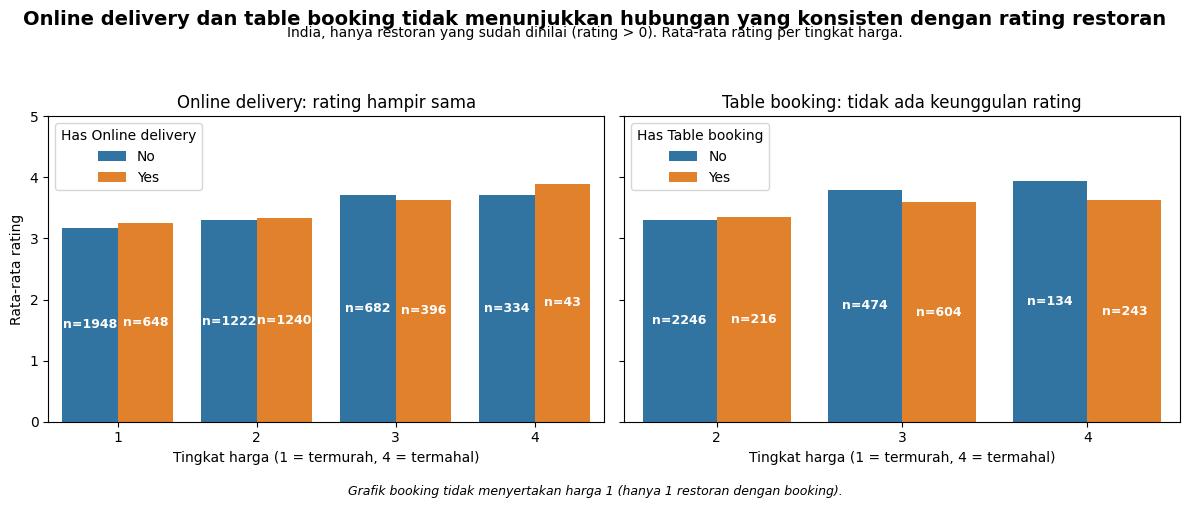

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.barplot(data=india_rated, x='Price range', y='Aggregate rating',
            hue='Has Online delivery', order=[1, 2, 3, 4], hue_order=HUE_ORDER,
            errorbar=None, ax=axes[0])
sns.barplot(data=data_tb, x='Price range', y='Aggregate rating',
            hue='Has Table booking', order=[2, 3, 4], hue_order=HUE_ORDER,
            errorbar=None, ax=axes[1])

add_counts(axes[0], india_rated, 'Has Online delivery', [1, 2, 3, 4])
add_counts(axes[1], data_tb, 'Has Table booking', [2, 3, 4])

axes[0].set_ylim(0, 5)
axes[0].set_title("Online delivery: rating hampir sama")
axes[1].set_title("Table booking: tidak ada keunggulan rating")

for ax in axes:
    ax.set_xlabel("Tingkat harga (1 = termurah, 4 = termahal)")
axes[0].set_ylabel("Rata-rata rating")
axes[1].set_ylabel("")

fig.text(0.5, 0.925, "India, hanya restoran yang sudah dinilai (rating > 0). Rata-rata rating per tingkat harga.",
         ha='center', fontsize=10)
fig.suptitle("Online delivery dan table booking tidak menunjukkan hubungan yang konsisten dengan rating restoran",
             fontsize=14, fontweight='bold')
fig.text(0.5, 0.01, "Grafik booking tidak menyertakan harga 1 (hanya 1 restoran dengan booking).",
         ha='center', fontsize=9, style='italic')

plt.tight_layout(rect=[0, 0.04, 1, 0.91])
plt.savefig('images/ratings_by_price.png', dpi=200, bbox_inches='tight')
plt.show()

Untuk delivery, batang Yes dan No hampir sama tinggi di tiap tingkat harga. Untuk booking, selisihnya kecil di harga 2, dan restoran tanpa booking sedikit lebih tinggi di harga 3 dan 4. Di semua kelompok, tinggi batang naik dari harga 1 ke 4, jadi tingkat harga lebih berkaitan dengan rating daripada fitur.

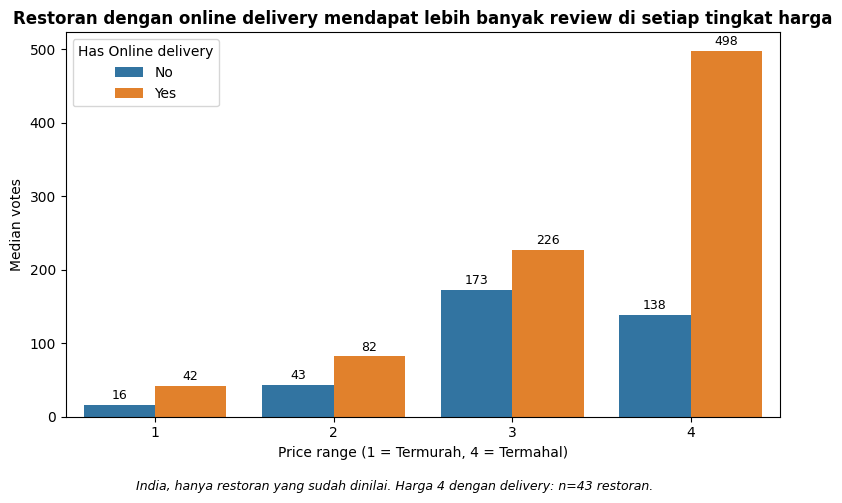

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(data=india_rated, x='Price range', y='Votes',
            hue='Has Online delivery', order=[1, 2, 3, 4], hue_order=HUE_ORDER,
            estimator='median', errorbar=None, ax=ax)

for c in ax.containers:
    ax.bar_label(c, fmt='%.0f', padding=2, fontsize=9)  # nilai median; hapus 2 baris ini jika tidak perlu

ax.set_title("Restoran dengan online delivery mendapat lebih banyak review di setiap tingkat harga",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Price range (1 = Termurah, 4 = Termahal)")
ax.set_ylabel("Median votes")

fig.text(0.5, 0.01, "India, hanya restoran yang sudah dinilai. Harga 4 dengan delivery: n=43 restoran.",
         ha='center', fontsize=9, style='italic')

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('images/votes_delivery.png', dpi=200, bbox_inches='tight')
plt.show()

Restoran dengan online delivery punya median votes lebih tinggi di setiap tingkat harga. Ini hubungan, belum tentu sebab-akibat.

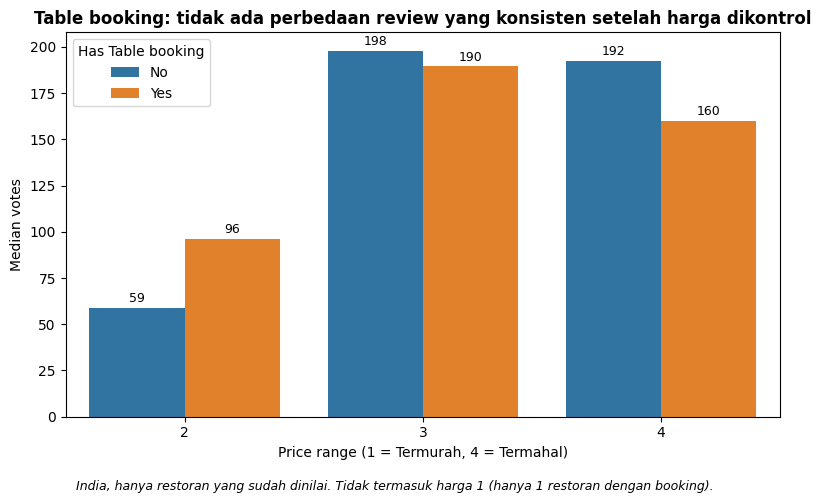

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(data=data_tb, x='Price range', y='Votes',
            hue='Has Table booking', order=[2, 3, 4], hue_order=HUE_ORDER,
            estimator='median', errorbar=None, ax=ax)

for c in ax.containers:
    ax.bar_label(c, fmt='%.0f', padding=2, fontsize=9)

ax.set_title("Table booking: tidak ada perbedaan review yang konsisten setelah harga dikontrol",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Price range (1 = Termurah, 4 = Termahal)")
ax.set_ylabel("Median votes")

fig.text(0.5, 0.01, "India, hanya restoran yang sudah dinilai. Tidak termasuk harga 1 (hanya 1 restoran dengan booking).",
         ha='center', fontsize=9, style='italic')

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('images/votes_booking.png', dpi=200, bbox_inches='tight')
plt.show()

Setelah harga dikontrol, table booking tidak menunjukkan perbedaan votes yang konsisten.

## Kesimpulan

**Temuan**
- Setelah restoran yang belum dinilai (rating 0) dibuang dan tingkat harga dikontrol, online delivery maupun table booking tidak menunjukkan hubungan yang konsisten dengan rating lebih tinggi pada 6.513 restoran yang sudah dinilai di India.
- Perbandingan mentah melebih-lebihkan efek fitur. Restoran yang belum dinilai kebanyakan tidak punya fitur, dan restoran dengan table booking menumpuk di tingkat harga tinggi yang memang ratingnya lebih tinggi.
- Tingkat harga adalah faktor yang paling berkaitan dengan rating.
- Online delivery berkaitan dengan lebih banyak review (median votes lebih tinggi) di setiap tingkat harga, sedangkan table booking tidak setelah harga dikontrol.

**Rekomendasi**
Menambah online delivery atau table booking kemungkinan tidak akan menaikkan rating dengan sendirinya. Delivery bisa membantu visibilitas lewat lebih banyak review, tetapi ini hubungan (asosiasi), bukan bukti sebab-akibat.

**Keterbatasan**
Data observasional; kota belum dikontrol; tidak ada uji signifikansi; kelompok kecil dibuang atau diberi catatan (table booking di harga 1, n=1; delivery di harga 4, n=43); hanya berlaku untuk India.